In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from joblib import Parallel, delayed
from datatools import *
import matplotlib.pyplot as plt

### 策略

In [ ]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')

In [ ]:
start_date = '2019-01-01'
end_date = '2026-04-30'
allstocks = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstocks = allstocks[~allstocks['ts_code'].str.contains('BJ')].ts_code.tolist()
load_start = (pd.Timestamp(start_date) - pd.DateOffset(years=1)).strftime('%Y-%m-%d')
price = get_price(codes=allstocks, start_date=load_start, end_date=end_date).rename(columns={'open':'next_open'})
price['next_open'] = price.groupby('ts_code')['next_open'].shift(-1)

加载价格数据...


In [ ]:
# ── 构建矩阵 ──────────────────────────────────────────────────────────────
dates = np.sort(price['trade_date'].unique())
universe = np.sort(price['ts_code'].unique())

high_pivot = price.pivot(index='trade_date', columns='ts_code', values='high').reindex(index=dates, columns=universe)
low_pivot = price.pivot(index='trade_date', columns='ts_code', values='low').reindex(index=dates, columns=universe)

n_dates, n_stocks = len(dates), len(universe)
print(f'矩阵: {n_dates} 交易日 × {n_stocks} 只股票')
N=18
M=600
cov_xy = high_pivot.rolling(N, min_periods=2).cov(low_pivot)
var_x = low_pivot.rolling(N, min_periods=2).var()
var_y = high_pivot.rolling(N, min_periods=2).var()
slope = cov_xy / var_x
r2 = (cov_xy ** 2) / (var_x * var_y)
slope_zscore = (slope - slope.rolling(M, min_periods=2).mean()) / slope.rolling(M, min_periods=2).std()
rsrs = slope*r2*slope_zscore
rsrs = rsrs.loc[start_date:end_date]
rsrs = rsrs.stack().reset_index().rename(columns={0:'rsrs'})

矩阵: 4955 交易日 × 5489 只股票


### 最低点策略

In [16]:
price['min_close_252'] = price.groupby('ts_code')['close'].rolling(window=252, min_periods=252).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close_252']
price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-84)
price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-84)
trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
trade_records['return_rate'] = (trade_records['sell_price'] - trade_records['buy_price']) / trade_records['buy_price']
trade_records = trade_records[['ts_code', 'trade_date', 'buy_price', 'sell_date', 'sell_price', 'return_rate']]

win_trades = len(trade_records[trade_records['return_rate'] > 0])
avg_return = trade_records['return_rate'].mean()
total_return = trade_records['return_rate'].sum()
strategy_summary = {
    '总交易次数': len(trade_records),
    '盈利次数': win_trades,
    '胜率': f"{win_trades / len(trade_records):.2%}",
    '平均单次收益率': f"{avg_return:.2%}",
    '累计收益率(简单累加)': f"{total_return:.2%}"
}

In [17]:
strategy_summary

{'总交易次数': 149551,
 '盈利次数': 90550,
 '胜率': '60.55%',
 '平均单次收益率': '10.12%',
 '累计收益率(简单累加)': '1513642.54%'}

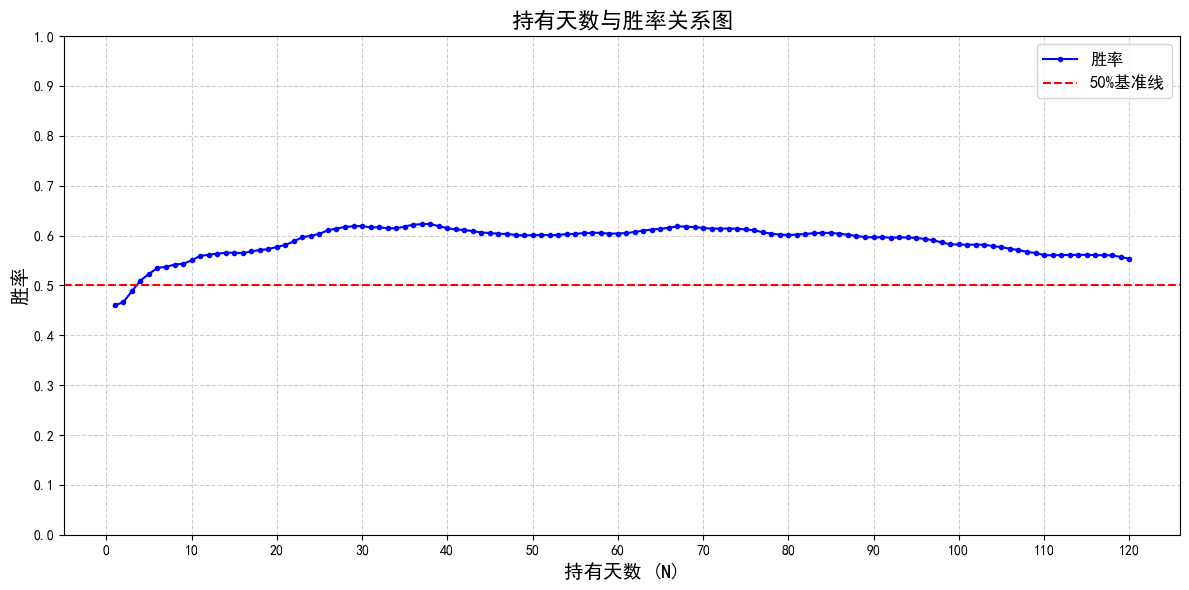

In [ ]:
price['min_close_252'] = price.groupby('ts_code')['close'].rolling(window=252, min_periods=252).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close_252']
holding_days_list = []
win_rates_list = []
# 3. 遍历 1 到 max_days 天，计算不同持有期下的胜率
for n in range(1, 120 + 1):
    price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-n)
    price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-n)
    trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
    # 计算该笔交易是否盈利（卖出价 > 买入价）
    win_rate = (trade_records['sell_price']>trade_records['next_open']).sum() / len(trade_records)
    holding_days_list.append(n)
    win_rates_list.append(win_rate)
# 返回计算结果的数据框，便于查看具体数值
result_price = pd.DataFrame({'holding_days': holding_days_list, 'win_rate': win_rates_list})

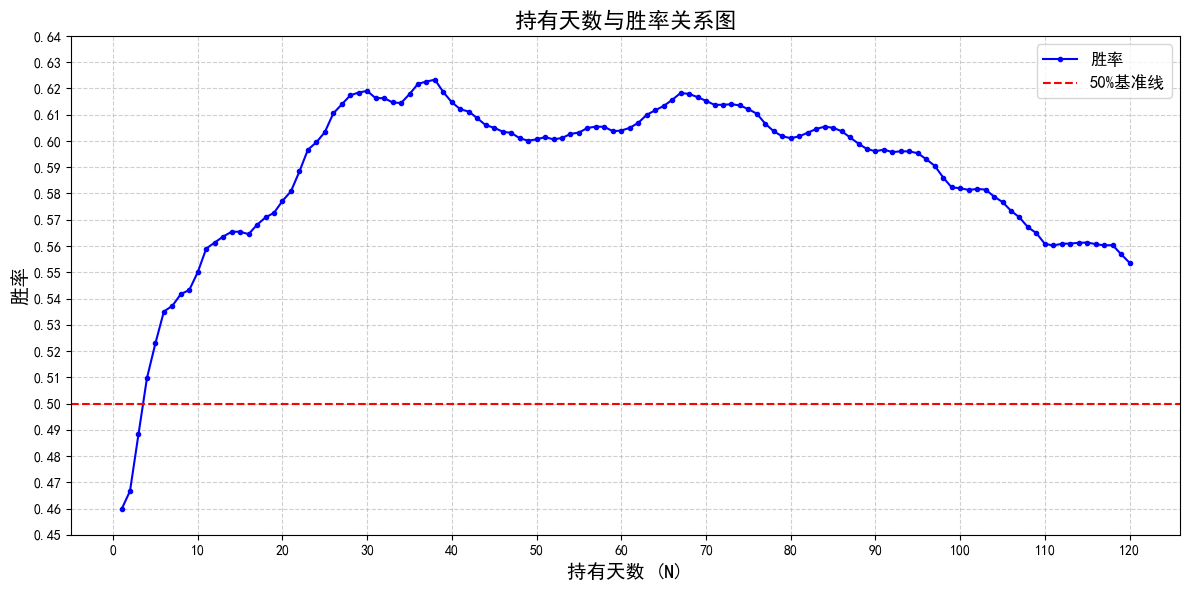

In [18]:
# 4. 绘制折线图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 6))
plt.plot(holding_days_list, win_rates_list, marker='o', markersize=3, linestyle='-', color='b', label='胜率')
# 添加50%基准线，便于判断盈亏优势
plt.axhline(y=0.5, color='r', linestyle='--', label='50%基准线')
plt.title('持有天数与胜率关系图', fontsize=16)
plt.xlabel('持有天数 (N)', fontsize=14)
plt.ylabel('胜率', fontsize=14)
plt.xticks(np.arange(0, 120 + 1, 10))
plt.yticks(np.arange(0.45, 0.65, 0.01))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
trade_records

,ts_code,trade_date,buy_price,sell_date,sell_price,return_rate
845547,000525.SZ,2019-01-14,100.980880,2019-07-15,97.039800,-0.039028
845658,000676.SZ,2019-01-14,76.561680,2019-07-15,70.615550,-0.077665
845684,000710.SZ,2019-01-14,100.958390,2019-07-15,122.185180,0.210253
845737,000792.SZ,2019-01-14,45.171970,2019-07-16,48.782780,0.079935
845897,002008.SZ,2019-01-14,344.751120,2019-07-15,406.469700,0.179024
...,...,...,...,...,...,...
8314988,600657.SH,2025-10-30,62.363500,2026-04-29,51.576300,-0.172973
8315166,600872.SH,2025-10-30,210.556416,2026-04-29,248.508270,0.180246
8315254,601006.SH,2025-10-30,15.226560,2026-04-29,14.036985,-0.078125
8315823,603529.SH,2025-10-30,74.119248,2026-04-29,54.900552,-0.259294
